In [5]:
import os
import joblib
import pandas as pd

import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [6]:
train = pd.read_csv('/Users/saidattaputta/Desktop/HomeValue-AI/data/processed/train_features.csv')

X = train.drop(columns=["SalePrice", "Id"])
y = train["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

preprocessor = joblib.load(
    "/Users/saidattaputta/Desktop/HomeValue-AI/artifacts/preprocessor.pkl"
)

assert list(X.columns) == list(preprocessor.feature_names_in_)

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

final_tuned_model = joblib.load(
    "/Users/saidattaputta/Desktop/HomeValue-AI/models/best_model.pkl"
)

In [7]:
shap.initjs()

In [8]:
feature_names = preprocessor.get_feature_names_out()

X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

explainer = shap.LinearExplainer(
    final_tuned_model,
    X_train_processed
)

shap_values = explainer(X_test_processed)

print(len(feature_names))

Background dataset has 1166 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1166 when initializing the masker.


242


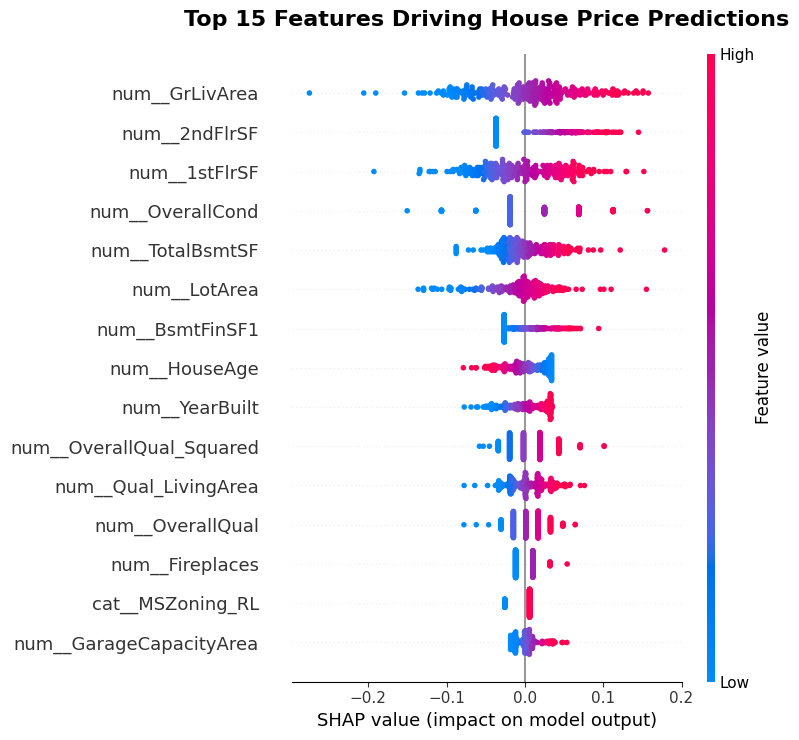

In [9]:
import matplotlib.pyplot as plt
import shap

# 1. Set up the plotting environment size
plt.figure(figsize=(12, 8))

# 2. Create the beeswarm summary plot 
# We look at the top 15 most influential features
shap.summary_plot(shap_values, max_display=15, show=False)

# 3. Clean up titles and display cleanly
plt.title("Top 15 Features Driving House Price Predictions", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()

plt.savefig("../artifacts/shap_global_summary.png")

plt.show()

In [10]:
print(type(shap_values))
print(shap_values.shape)

print(type(shap_values.feature_names))
print(len(shap_values.feature_names))

print(X_test_processed.shape)

print(len(preprocessor.get_feature_names_out()))

<class 'shap._explanation.Explanation'>
(292, 242)
<class 'list'>
242
(292, 242)
242


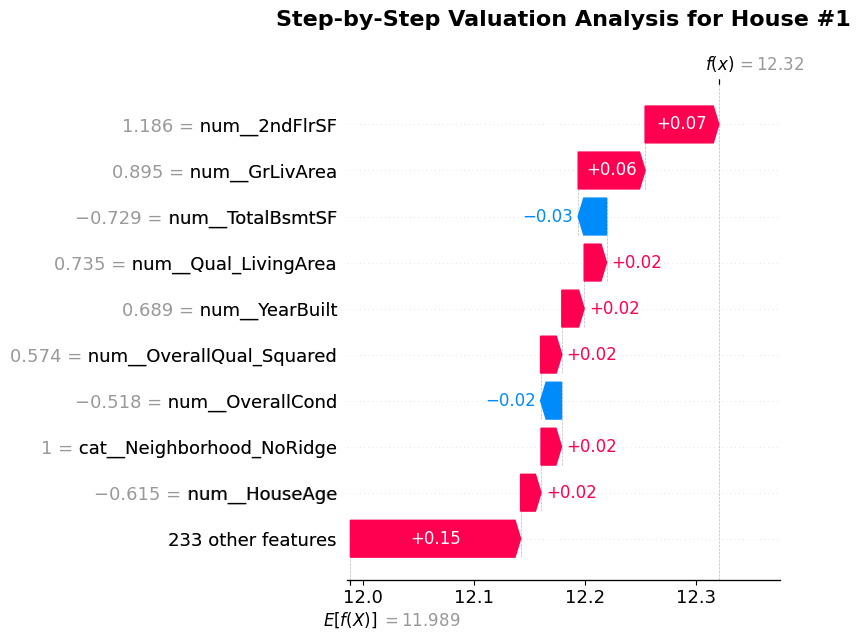

In [11]:
os.makedirs("../artifacts", exist_ok=True)

single_house_explanation = shap_values[0]

plt.figure(figsize=(12, 8))

shap.plots.waterfall(
    single_house_explanation,
    max_display=10,
    show=False
)

plt.title(
    "Step-by-Step Valuation Analysis for House #1",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.savefig(
    "../artifacts/shap_local_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
import os
import joblib

os.makedirs('../artifacts',exist_ok=True)

joblib.dump(shap_values,'../artifacts/shap_values.pkl')

['../artifacts/shap_values.pkl']